In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from missingno import matrix
from missingno import heatmap

pd.set_option('display.max_columns',None)

import warnings
warnings.filterwarnings("ignore")

In [5]:
field_df = pd.read_csv("C:/Users/admin/Documents/Projects/maize-yield-optimization-rwanda/data/raw/Field_Level.csv")
plot_df = pd.read_csv("C:/Users/admin/Documents/Projects/maize-yield-optimization-rwanda/data/raw/Plot_Level.csv")
soil_df = pd.read_csv("C:/Users/admin/Documents/Projects/maize-yield-optimization-rwanda/data/raw/Soil_PL.csv")

In [7]:
datasets = {
    "Field" : field_df,
    "Plot" : plot_df,
    "Soil" : soil_df   
}
for name,df in datasets.items():
    print(f"\n{name}")
    
    print("-"*30)
    
    print("Shape:",df.shape)


Field
------------------------------
Shape: (399, 19)

Plot
------------------------------
Shape: (1598, 27)

Soil
------------------------------
Shape: (736, 5)


In [9]:
for name,df in datasets.items():
    
    print("\n")
    print(name)
    
    display(df.info())
    
    display(df.head())
    
    display(df.describe(include='all'))



Field
<class 'pandas.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   block_id               399 non-null    str    
 1   season                 399 non-null    str    
 2   district               399 non-null    str    
 3   cell                   399 non-null    str    
 4   agzone                 399 non-null    str    
 5   meg_env                399 non-null    str    
 6   lat                    399 non-null    float64
 7   long                   399 non-null    float64
 8   alt                    399 non-null    float64
 9   landscape_pos          399 non-null    str    
 10  slope_pos              242 non-null    str    
 11  fert_rank              399 non-null    str    
 12  soil_color             399 non-null    str    
 13  rockness               242 non-null    str    
 14  soil_depth             242 non-null    str    
 15  slope    

None

,block_id,season,district,cell,agzone,meg_env,lat,long,alt,landscape_pos,slope_pos,fert_rank,soil_color,rockness,soil_depth,slope,trial_follower_gender,trialfield_home_min,cult_land
0,adfa31ad-95bf-453d-94f1-d163a97756ee,21A,Rwamagana,Akanzu,Eastern Ridges,Low-Mid-Dry,-2.021072,30.334707,1638.04,Hills,Backslope,medium,red_less,no_rocks,shallow,3,Male,4.0,20.0
1,d8807f25-e675-49ae-87a3-d228eca23c72,21A,Rwamagana,Akanzu,Eastern Ridges,Low-Mid-Dry,-2.021166,30.334817,1622.55,Hills,Backslope,medium,red_more,less_rocky,shallow,4,Male,5.0,19.0
2,262efa71-6ff4-4e18-b6f1-0c3d293504c0,21A,Rwamagana,Akanzu,Eastern Ridges,Low-Mid-Dry,-2.020386,30.338258,1610.46,Hills,Backslope,medium,red_less,no_rocks,deep,3,Male,15.0,18.0
3,95c016dd-908a-4f07-9e49-926e9a9f4f19,21A,Rwamagana,Akanzu,Eastern Ridges,Low-Mid-Dry,-2.020589,30.337583,1620.42,Hills,Backslope,medium,red_less,no_rocks,deep,3,Male,3.0,18.0
4,1d5c61a0-ca6b-4db8-87c3-5ca46c7cad6d,21A,Rwamagana,Akanzu,Eastern Ridges,Low-Mid-Dry,-2.018119,30.338658,1614.13,Hills,Backslope,medium,black_less,less_rocky,shallow,4,Female,5.0,10.0


,block_id,season,district,cell,agzone,meg_env,lat,long,alt,landscape_pos,slope_pos,fert_rank,soil_color,rockness,soil_depth,slope,trial_follower_gender,trialfield_home_min,cult_land
count,399,399,399,399,399,399,399.000000,399.000000,399.000000,399,242,399,399,242,242,399.000000,390,118.000000,390.000000
unique,399,3,14,22,7,4,NaN,NaN,NaN,3,6,3,7,3,2,NaN,2,NaN,NaN
top,adfa31ad-95bf-453d-94f1-d163a97756ee,22A,Burera,Tyazo,Eastern Ridges,Highlands,NaN,NaN,NaN,Hills,Backslope,medium,red_less,no_rocks,deep,NaN,Male,NaN,NaN
freq,1,193,63,30,85,142,NaN,NaN,NaN,340,158,354,212,187,146,NaN,210,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,-2.053361,29.754235,1750.779398,NaN,NaN,NaN,NaN,NaN,NaN,10.669173,NaN,12.838983,42.950000
std,NaN,NaN,NaN,NaN,NaN,NaN,0.340776,0.419353,318.558097,NaN,NaN,NaN,NaN,NaN,NaN,7.180083,NaN,16.225953,35.863415
min,NaN,NaN,NaN,NaN,NaN,NaN,-2.554515,29.084352,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,1.000000,2.500000
25%,NaN,NaN,NaN,NaN,NaN,NaN,-2.360176,29.473978,1503.110000,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,3.000000,18.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,-2.074883,29.737257,1701.210000,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,5.000000,30.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,-1.835101,29.907522,2050.990000,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,NaN,15.000000,55.000000




Plot
<class 'pandas.DataFrame'>
RangeIndex: 1598 entries, 0 to 1597
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   block_id            1598 non-null   str    
 1   season              1598 non-null   str    
 2   plot_id             1598 non-null   str    
 3   treat_code          1598 non-null   str    
 4   treat_details       1598 non-null   str    
 5   urea_rate_timing    1598 non-null   str    
 6   crop                1598 non-null   str    
 7   prior_season_crop   1138 non-null   str    
 8   planting_date       1598 non-null   str    
 9   compost_tha         1598 non-null   int64  
 10  compost_quality     1590 non-null   str    
 11  seed_variety        1598 non-null   str    
 12  seeds_kgha          1598 non-null   int64  
 13  dap_kgha            1598 non-null   int64  
 14  urea_planting_kgha  1598 non-null   int64  
 15  germ_count_date     1598 non-null   str    
 16  germinatio

...

,block_id,season,plot_id,treat_code,treat_details,urea_rate_timing,crop,prior_season_crop,planting_date,compost_tha,compost_quality,seed_variety,seeds_kgha,dap_kgha,urea_planting_kgha,germ_count_date,germination_rate,urea_V6_date,urea_V6_kgha,urea_V10_date,urea_V10_kgha,urea_total_kgha,N_kgha,silking_date,R3_date,harvest_date,yield_tha
count,1598,1598,1598,1598,1598,1598,1598,1138,1598,1598.000000,1590,1598,1598.000000,1598.000000,1598.000000,1598,1598.000000,1598,1598.000000,286,1598.000000,1598.000000,1598.000000,1589,1592,1598,1598.000000
unique,401,3,1598,4,5,4,2,35,125,NaN,3,4,NaN,NaN,NaN,101,NaN,102,NaN,73,NaN,NaN,NaN,127,130,152,NaN
top,adfa31ad-95bf-453d-94f1-d163a97756ee,22A,adfa31ad-95bf-453d-94f1-d163a97756ee-21A-A,C,DAP 1Kg/Are + Urea 0.5Kg/Are at V6 + Urea 0.5K...,Urea 1kg/Are(V6 + V10),Maize,Beans,9/30/2020,NaN,Well_decomposed,MV_605,NaN,NaN,NaN,10/14/2021,NaN,11/11/2020,NaN,12/4/2020,NaN,NaN,NaN,1/5/2022,1/5/2022,3/10/2022,NaN
freq,4,771,1,401,401,401,1089,460,88,NaN,995,641,NaN,NaN,NaN,52,NaN,80,NaN,15,NaN,NaN,NaN,49,68,40,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.359825,NaN,NaN,34.779099,100.358573,12.488736,NaN,85.436170,NaN,63.014393,NaN,12.642678,88.105757,58.586358,NaN,NaN,NaN,4.863899
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.226776,NaN,NaN,6.823338,1.475650,21.732467,NaN,14.740056,NaN,21.849268,NaN,21.854774,21.816493,10.045407,NaN,NaN,NaN,2.178287
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,18.000000,95.000000,0.000000,NaN,20.000000,NaN,48.000000,NaN,0.000000,48.000000,40.000000,NaN,NaN,NaN,0.490000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,NaN,NaN,30.000000,100.000000,0.000000,NaN,78.000000,NaN,50.000000,NaN,0.000000,96.250000,62.000000,NaN,NaN,NaN,3.510000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,34.000000,100.000000,0.000000,NaN,90.500000,NaN,50.000000,NaN,0.000000,100.000000,64.000000,NaN,NaN,NaN,4.820000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.000000,NaN,NaN,40.000000,100.000000,0.000000,NaN,97.000000,NaN,96.750000,NaN,48.750000,100.000000,64.000000,NaN,NaN,NaN,6.090000




Soil
<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   plot_id  736 non-null    str    
 1   pH       734 non-null    float64
 2   tot_N    0 non-null      float64
 3   org_C    0 non-null      float64
 4   sand     0 non-null      float64
dtypes: float64(4), str(1)
memory usage: 28.9 KB


None

,plot_id,pH,tot_N,org_C,sand
0,adfa31ad-95bf-453d-94f1-d163a97756ee-21A-A,5.21,NaN,NaN,NaN
1,d8807f25-e675-49ae-87a3-d228eca23c72-21A-A,5.75,NaN,NaN,NaN
2,262efa71-6ff4-4e18-b6f1-0c3d293504c0-21A-A,5.81,NaN,NaN,NaN
3,95c016dd-908a-4f07-9e49-926e9a9f4f19-21A-A,5.75,NaN,NaN,NaN
4,1d5c61a0-ca6b-4db8-87c3-5ca46c7cad6d-21A-A,6.13,NaN,NaN,NaN


,plot_id,pH,tot_N,org_C,sand
count,736,734.000000,0.0,0.0,0.0
unique,736,NaN,NaN,NaN,NaN
top,adfa31ad-95bf-453d-94f1-d163a97756ee-21A-A,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,5.701076,NaN,NaN,NaN
std,NaN,0.591021,NaN,NaN,NaN
min,NaN,4.160000,NaN,NaN,NaN
25%,NaN,5.190000,NaN,NaN,NaN
50%,NaN,5.685000,NaN,NaN,NaN
75%,NaN,6.197500,NaN,NaN,NaN


In [10]:
for name,df in datasets.items():
    
    missing=(df.isnull().sum()/len(df))*100
    
    missing=missing.sort_values(
        ascending=False
    )
    
    display(
        missing[missing>0]
    )
    

trialfield_home_min      70.426065
slope_pos                39.348371
soil_depth               39.348371
rockness                 39.348371
trial_follower_gender     2.255639
cult_land                 2.255639
dtype: float64

urea_V10_date        82.102628
prior_season_crop    28.785982
silking_date          0.563204
compost_quality       0.500626
R3_date               0.375469
dtype: float64

tot_N    100.000000
sand     100.000000
org_C    100.000000
pH         0.271739
dtype: float64

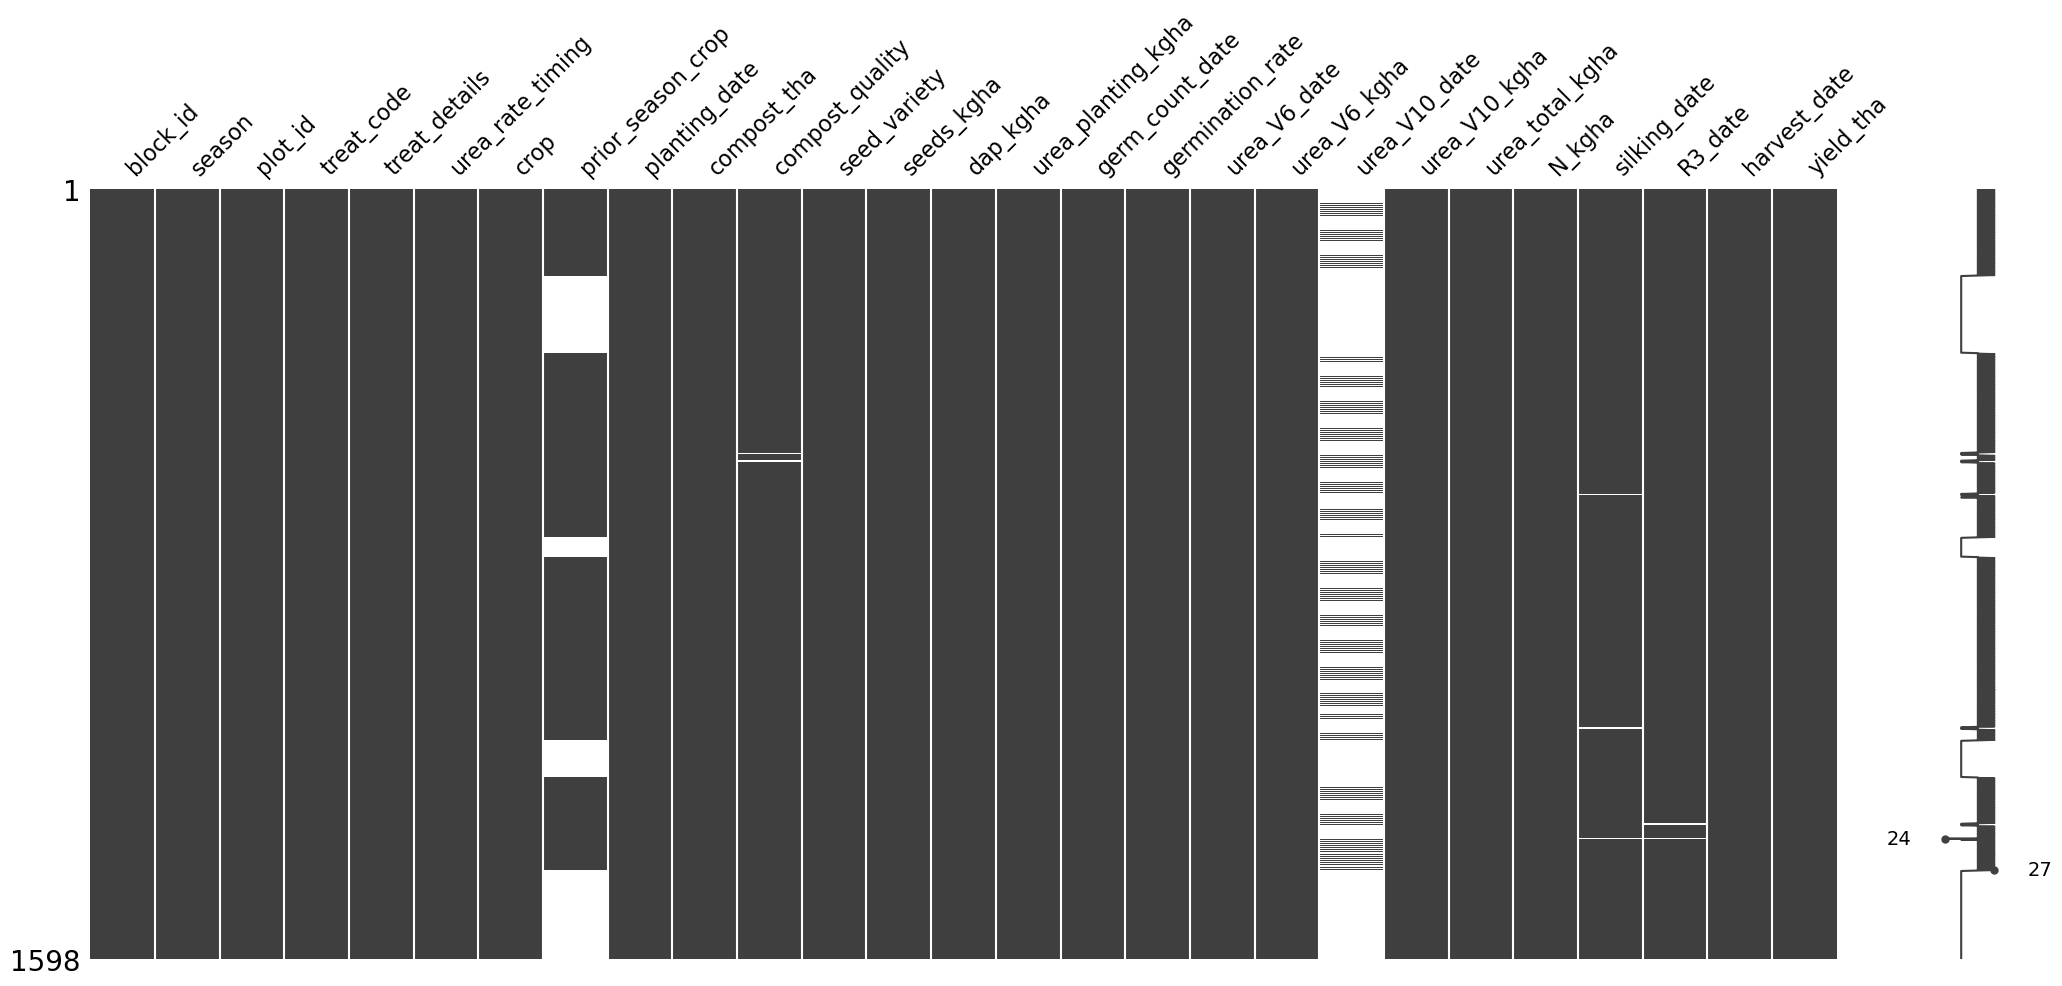

In [11]:
matrix(plot_df)

plt.show()

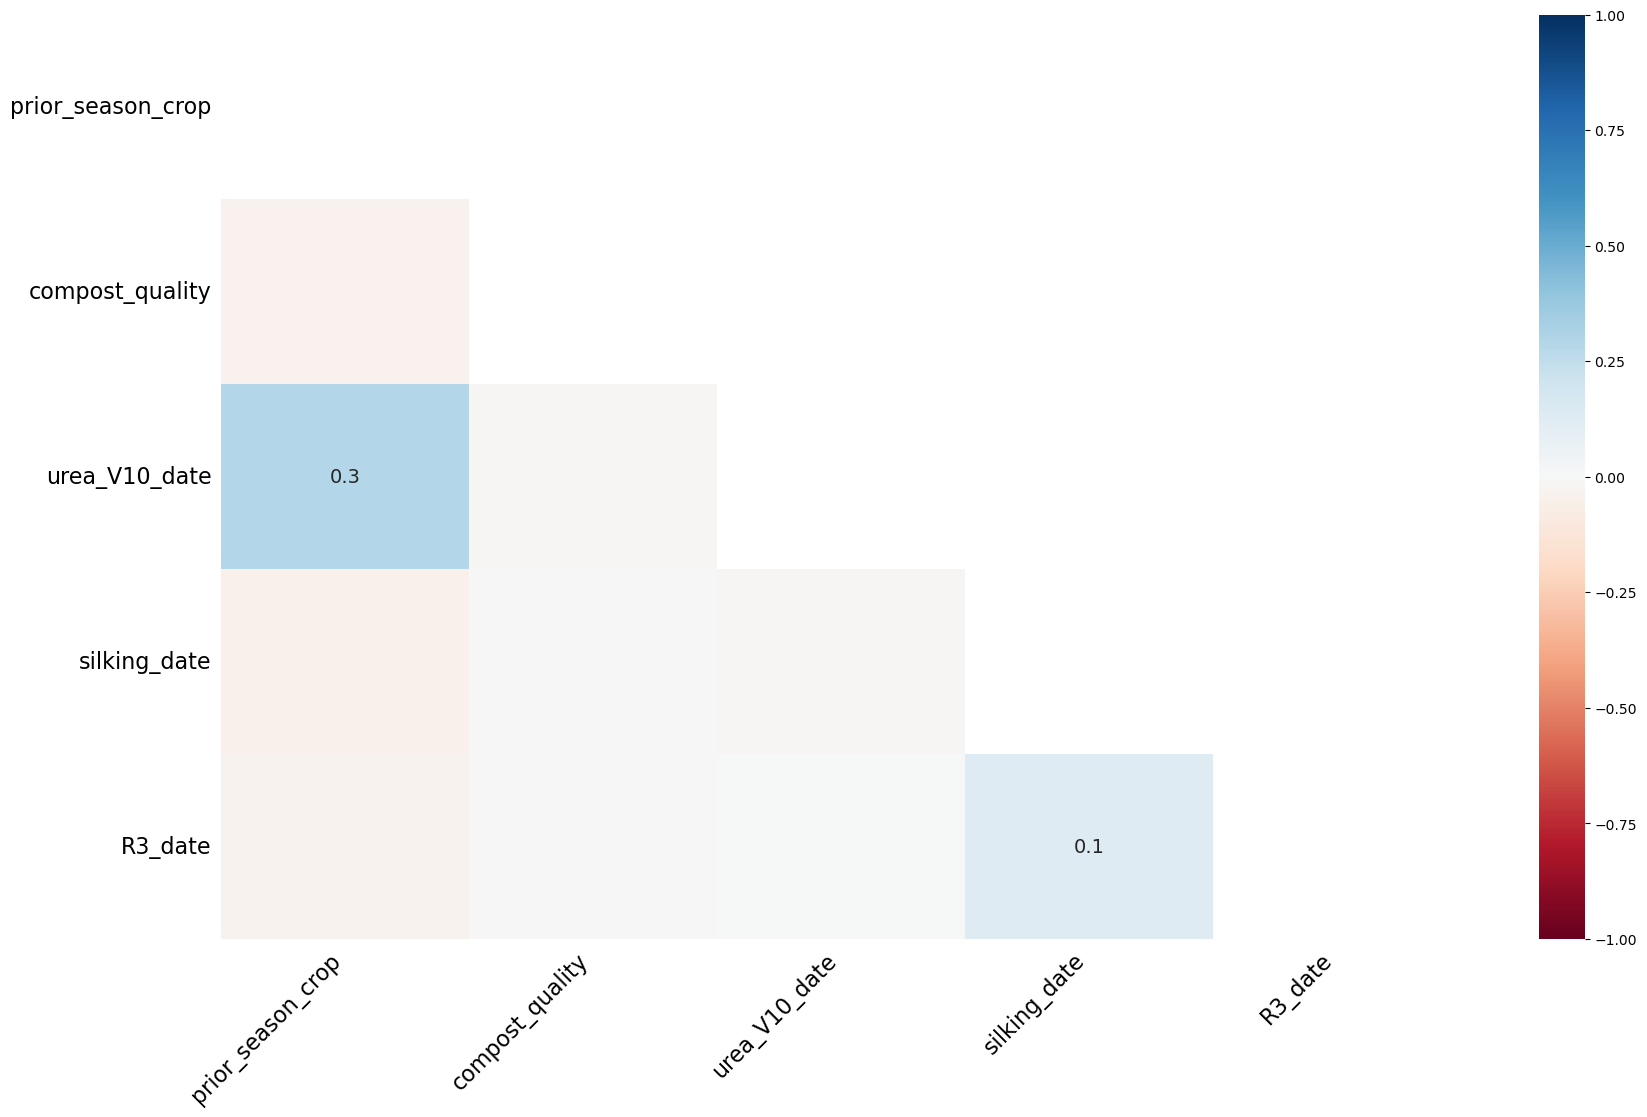

In [12]:
heatmap(plot_df)

plt.show()